# MA / EMA / DEMA / TEMA  
Эксперимент на **стационарном** и **нестационарном** рядах + выбор оптимальной модели.

**Данные:**
- `daily-total-female-births-in-cal.csv` — дневной ряд (обычно близок к стационарному).
- `international-airline-passengers.csv` — месячный ряд с трендом/сезонностью (нестационарный).

**Пайплайн:**
1) Загружаем 2 ряда.  
2) Разбиваем: всё кроме последнего месяца — `train`, последний месяц — `test`.  
3) На `train` подбираем параметры моделей **MA, EMA, DEMA, TEMA** (grid search + TimeSeriesSplit).  
4) Строим **one-step-ahead** прогноз на `test` (последний месяц).  
5) Считаем метрики MAE / MSE / RMSE и выбираем лучшую модель для каждого ряда.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple, Callable

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 1) Загрузка данных

In [4]:
STAT_PATH = r"..\data\raw\daily-total-female-births-in-cal.csv"
NONSTAT_PATH = r"..\data\raw\international-airline-passengers.csv"

# Запуск локально
# STAT_PATH = "daily-total-female-births-in-cal.csv"
# NONSTAT_PATH = "international-airline-passengers.csv"

df_stat = pd.read_csv(STAT_PATH, parse_dates=["Date"]).sort_values("Date").set_index("Date")
y_stat = df_stat["Count"].astype(float)

df_non = pd.read_csv(NONSTAT_PATH).copy()
df_non["Month"] = pd.to_datetime(df_non["Month"])
df_non = df_non.sort_values("Month").set_index("Month")
y_non = df_non["Count"].astype(float)

print("Stationary-like series:", y_stat.index.min(), "->", y_stat.index.max(), "len=", len(y_stat))
print("Non-stationary series:", y_non.index.min(), "->", y_non.index.max(), "len=", len(y_non))


Stationary-like series: 1959-01-01 00:00:00 -> 1959-12-31 00:00:00 len= 365
Non-stationary series: 1949-01-01 00:00:00 -> 1960-12-01 00:00:00 len= 144


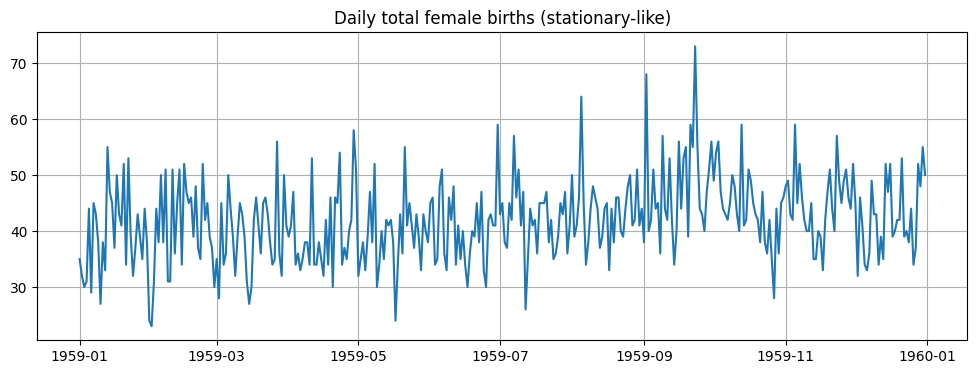

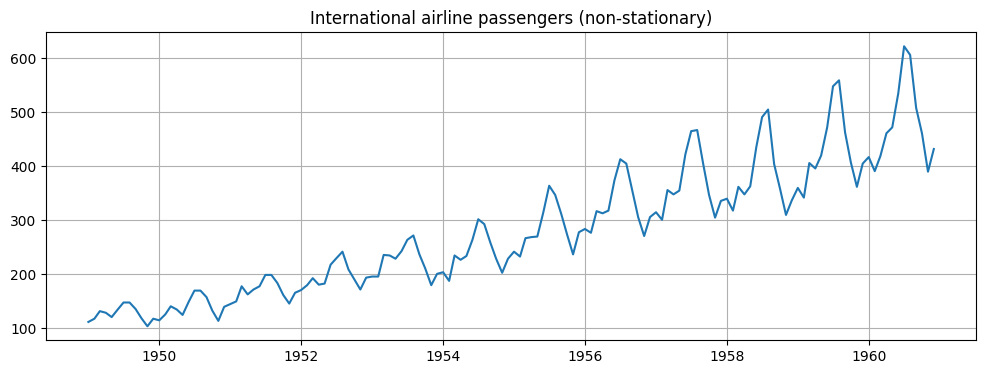

In [5]:
def plot_series(y: pd.Series, title: str):
    plt.figure(figsize=(12,4))
    plt.plot(y.index, y.values)
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_series(y_stat, "Daily total female births (stationary-like)")
plot_series(y_non, "International airline passengers (non-stationary)")


## 2) Сплит: последний месяц — тест

In [9]:
from typing import Tuple

def split_train_test_smart(y: pd.Series, n_months_if_monthly: int = 12) -> Tuple[pd.Series, pd.Series]:
    if not isinstance(y.index, pd.DatetimeIndex):
        raise ValueError("Ожидается DatetimeIndex")

    y = y.sort_index().dropna()

    # грубо определим "месячный" по медианному шагу
    median_step_days = y.index.to_series().diff().dt.days.median()

    if median_step_days is not None and median_step_days >= 28:
        # месячные данные
        if len(y) <= n_months_if_monthly:
            raise ValueError("Слишком мало данных для теста.")
        return y.iloc[:-n_months_if_monthly].copy(), y.iloc[-n_months_if_monthly:].copy()
    else:
        # дневные/чаще — последний месяц
        last_month = y.index.max().to_period("M")
        test_mask = (y.index.to_period("M") == last_month)
        y_train = y.loc[~test_mask].copy()
        y_test  = y.loc[test_mask].copy()
        if len(y_test) < 2:
            raise ValueError("Слишком мало точек в последнем месяце.")
        return y_train, y_test

y_stat_train, y_stat_test = split_train_test_smart(y_stat, n_months_if_monthly=12)
y_non_train, y_non_test   = split_train_test_smart(y_non,  n_months_if_monthly=12)


## 3) Реализация MA / EMA / DEMA / TEMA (быстро, без пересчёта всей истории)

Важно: прогнозируем **one-step-ahead**.  
Чтобы предсказать значение в момент `t`, используем только факты до `t-1`.

- **MA(w)**: среднее последних `w` наблюдений.  
- **EMA(span)**: экспоненциальное сглаживание с `alpha = 2/(span+1)`.  
- **DEMA(span)**: `2*EMA1 - EMA2`.  
- **TEMA(span)**: `3*EMA1 - 3*EMA2 + EMA3`.


In [10]:
def alpha_from_span(span: int) -> float:
    span = int(span)
    if span < 1:
        raise ValueError("span must be >= 1")
    return 2.0 / (span + 1.0)

def predict_one_step_array(y: np.ndarray, model: str, param: int) -> np.ndarray:
    """Возвращает предсказания для t=1..n-1 (длина n-1), где pred[t] = forecast(y[t])."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2:
        return np.array([])

    if model == "MA":
        w = max(1, int(param))
        preds = np.empty(n-1, dtype=float)
        # поддерживаем сумму окна на фактах до t-1
        window_sum = y[0]
        window = [y[0]]
        for t in range(1, n):
            preds[t-1] = window_sum / len(window)
            # обновляем окно фактом y[t]
            window.append(y[t])
            window_sum += y[t]
            if len(window) > w:
                window_sum -= window.pop(0)
        return preds

    a = alpha_from_span(param)
    if model == "EMA":
        preds = np.empty(n-1, dtype=float)
        ema1 = y[0]
        for t in range(1, n):
            preds[t-1] = ema1
            ema1 = a*y[t] + (1-a)*ema1
        return preds

    if model == "DEMA":
        preds = np.empty(n-1, dtype=float)
        ema1 = y[0]
        ema2 = y[0]
        for t in range(1, n):
            preds[t-1] = 2*ema1 - ema2
            ema1 = a*y[t] + (1-a)*ema1
            ema2 = a*ema1 + (1-a)*ema2
        return preds

    if model == "TEMA":
        preds = np.empty(n-1, dtype=float)
        ema1 = y[0]
        ema2 = y[0]
        ema3 = y[0]
        for t in range(1, n):
            preds[t-1] = 3*ema1 - 3*ema2 + ema3
            ema1 = a*y[t] + (1-a)*ema1
            ema2 = a*ema1 + (1-a)*ema2
            ema3 = a*ema2 + (1-a)*ema3
        return preds

    raise ValueError(f"Unknown model: {model}")


## 4) Подбор параметров на train (TimeSeriesSplit)

Метрика для подбора: **RMSE** (можно поменять на MAE/MSE).  
Параметры:
- MA: `window`
- EMA/DEMA/TEMA: `span`

Чтобы вычисления были быстрыми, для каждого фолда мы делаем one-step-ahead прогноз на валидации с последовательным обновлением состояния.


In [11]:
def rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

METRICS = {
    "MAE": lambda y, p: float(mean_absolute_error(y, p)),
    "MSE": lambda y, p: float(mean_squared_error(y, p)),
    "RMSE": rmse,
}

@dataclass
class ModelCfg:
    name: str
    param_name: str
    grid: List[int]

MODEL_CFGS = [
    ModelCfg("MA", "window", list(range(2, 61))),   # окна 2..60
    ModelCfg("EMA", "span", list(range(2, 61))),
    ModelCfg("DEMA", "span", list(range(2, 61))),
    ModelCfg("TEMA", "span", list(range(2, 61))),
]

def cv_score(y_train: pd.Series, model: str, param: int, metric: str = "RMSE", n_splits: int = 5) -> float:
    metric_fn = METRICS[metric]
    tscv = TimeSeriesSplit(n_splits=n_splits)
    y_vals = y_train.values.astype(float)
    scores = []
    for tr_idx, val_idx in tscv.split(y_vals):
        y_tr = y_vals[tr_idx]
        y_val = y_vals[val_idx]
        # Склеиваем для удобства: на вал предсказываем, имея историю y_tr
        y_all = np.concatenate([y_tr, y_val])
        preds_all = predict_one_step_array(y_all, model, param)  # preds for positions 1..end
        # Нас интересуют предсказания для y_val: это индексы, соответствующие t in val_idx
        # t в общем массиве начинается с len(y_tr) .. len(y_all)-1
        start = len(y_tr) - 1  # потому что preds начинаются с t=1
        preds_val = preds_all[start : start + len(y_val)]
        scores.append(metric_fn(y_val, preds_val))
    return float(np.mean(scores))

def tune_model(y_train: pd.Series, cfg: ModelCfg, metric: str = "RMSE", n_splits: int = 5):
    rows = []
    best_p = None
    best_s = 1e18
    for p in cfg.grid:
        s = cv_score(y_train, cfg.name, p, metric=metric, n_splits=n_splits)
        rows.append({"model": cfg.name, cfg.param_name: p, f"cv_{metric}": s})
        if s < best_s:
            best_s = s
            best_p = p
    table = pd.DataFrame(rows).sort_values(f"cv_{metric}", ascending=True).reset_index(drop=True)
    return int(best_p), table


## 5) Прогноз на тесте и метрики

In [12]:
def forecast_last_month(y_train: pd.Series, y_test: pd.Series, model: str, param: int) -> pd.Series:
    y_all = np.concatenate([y_train.values.astype(float), y_test.values.astype(float)])
    preds_all = predict_one_step_array(y_all, model, param)
    # предсказания для теста начинаются с момента t = len(train)
    start = len(y_train) - 1
    preds_test = preds_all[start : start + len(y_test)]
    return pd.Series(preds_test, index=y_test.index)

def evaluate_models(y_train: pd.Series, y_test: pd.Series, tune_metric: str = "RMSE", n_splits: int = 5):
    best_params = {}
    tune_tables = {}
    # 1) подбор параметров
    for cfg in MODEL_CFGS:
        best_p, table = tune_model(y_train, cfg, metric=tune_metric, n_splits=n_splits)
        best_params[cfg.name] = best_p
        tune_tables[cfg.name] = table

    # 2) оценка на тесте
    rows = []
    preds = {}
    for model, p in best_params.items():
        y_pred = forecast_last_month(y_train, y_test, model, p)
        preds[model] = y_pred
        rows.append({
            "model": model,
            "param": p,
            "MAE": METRICS["MAE"](y_test.values, y_pred.values),
            "MSE": METRICS["MSE"](y_test.values, y_pred.values),
            "RMSE": METRICS["RMSE"](y_test.values, y_pred.values),
        })
    eval_df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return best_params, tune_tables, eval_df, preds

best_p_stat, tune_stat, eval_stat, preds_stat = evaluate_models(y_stat_train, y_stat_test, tune_metric="RMSE", n_splits=5)
best_p_non, tune_non, eval_non, preds_non = evaluate_models(y_non_train, y_non_test, tune_metric="RMSE", n_splits=5)

print("=== Stationary-like (births) ===")
display(eval_stat)
print("\n=== Non-stationary (passengers) ===")
display(eval_non)


=== Stationary-like (births) ===


,model,param,MAE,MSE,RMSE
0,EMA,40,5.761596,47.329846,6.879669
1,DEMA,60,5.726666,48.021670,6.929767
2,MA,30,5.893548,48.297384,6.949632
3,TEMA,60,5.725193,48.847917,6.989129



=== Non-stationary (passengers) ===


,model,param,MAE,MSE,RMSE
0,TEMA,2,46.105817,2921.592878,54.051761
1,DEMA,2,47.957141,3201.909554,56.585418
2,EMA,2,51.254006,3836.919146,61.942870
3,MA,2,56.166667,4568.541667,67.590988


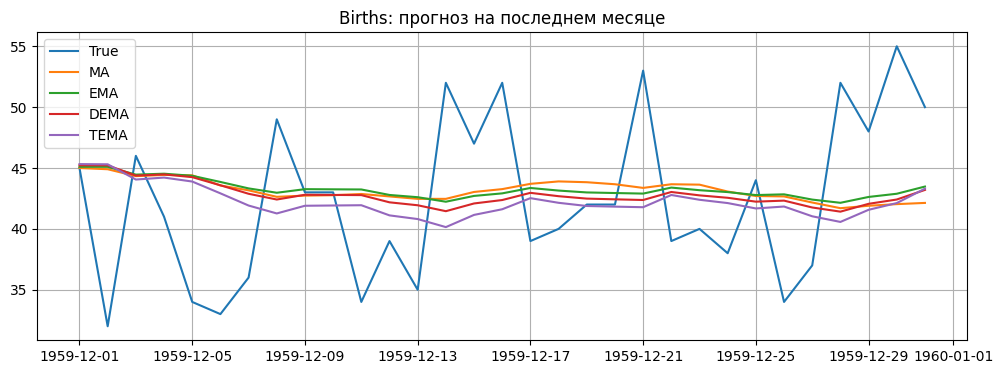

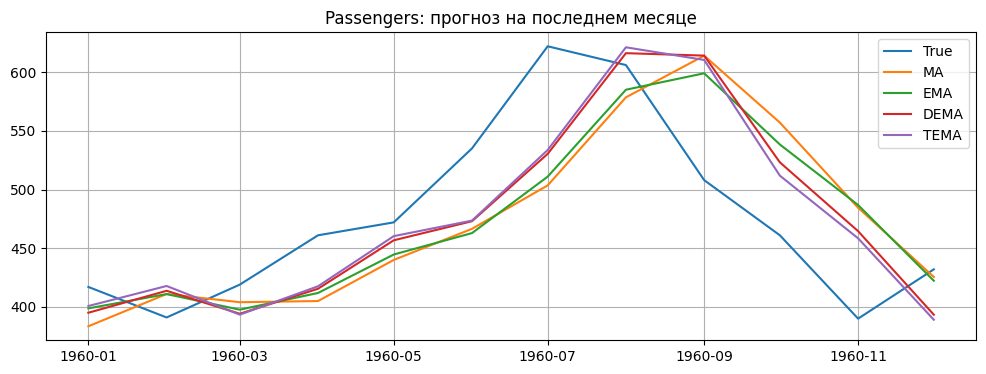

In [13]:
def plot_test_forecasts(y_test: pd.Series, preds: Dict[str, pd.Series], title: str):
    plt.figure(figsize=(12,4))
    plt.plot(y_test.index, y_test.values, label="True")
    for m, s in preds.items():
        plt.plot(s.index, s.values, label=m)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_test_forecasts(y_stat_test, preds_stat, "Births: прогноз на последнем месяце")
plot_test_forecasts(y_non_test, preds_non, "Passengers: прогноз на последнем месяце")


## 6) Вывод: лучшая модель для каждого ряда + обоснование

In [14]:
def summarize(eval_df: pd.DataFrame, series_name: str):
    best = eval_df.iloc[0].to_dict()
    print(f"Лучшая модель для '{series_name}' по RMSE на тесте (последний месяц):")
    print(best)
    print()

summarize(eval_stat, "стационарный (births)")
summarize(eval_non, "нестационарный (passengers)")


Лучшая модель для 'стационарный (births)' по RMSE на тесте (последний месяц):
{'model': 'EMA', 'param': 40, 'MAE': 5.7615961502041815, 'MSE': 47.329846022053765, 'RMSE': 6.879669034339789}

Лучшая модель для 'нестационарный (passengers)' по RMSE на тесте (последний месяц):
{'model': 'TEMA', 'param': 2, 'MAE': 46.105817378035134, 'MSE': 2921.592878425687, 'RMSE': 54.051761103831645}



Выводы по эксперименту MA-класса (MA / EMA / DEMA / TEMA)
1) Стационарный ряд (births)

Лучшая модель: EMA (span = 40)
Качество на тесте (последний месяц):

MAE = 5.76
MSE = 47.33
RMSE = 6.88

Обоснование выбора:
Стационарный ряд не имеет устойчивого тренда и сильной сезонности - колеблется вокруг некоторого среднего уровня. В таких условиях ключевая задача модели - сгладить шум, не пытаясь “догонять” уровень.
EMA с большим span (=40) даёт сильное сглаживание, то есть меньше реагирует на случайные всплески и провалы. Это снижает ошибку на горизонте “последний месяц”, поэтому именно EMA оказалась оптимальной по RMSE.

2) Нестационарный ряд (passengers)
Лучшая модель: TEMA (span = 2)
Качество на тесте (последний месяц):

MAE = 46.11
MSE = 2921.59
RMSE = 54.05

Обоснование выбора:
Ряд пассажиров - выраженно нестационарный: присутствуют тренд + сезонность, поэтому простое сглаживание (MA/EMA) часто даёт запаздывание (lag): модель “отстаёт” от роста и падений.
TEMA (тройное экспоненциальное сглаживание) специально сделана, чтобы уменьшать лаг и быстрее адаптироваться к изменениям уровня.
Малый span (=2) делает модель максимально “быстрой” - она сильнее реагирует на свежие значения и лучше успевает за динамикой. Поэтому на последнем месяце именно TEMA дала минимальный RMSE.

По графику это видно: все сглаживания плохо ловят резкий спад осенью 1960, но TEMA/DEMA реагируют быстрее, чем MA/EMA - отсюда выигрыш по ошибке.

Итог
Для стационарного ряда оптимальна EMA(40), потому что лучше всего подавляет шум и не создаёт лишней “реактивности”.
Для нестационарного ряда оптимальна TEMA(2), потому что она быстрее адаптируется к изменениям уровня и меньше запаздывает на тренде/сезонности.